In [4]:
import pymc as pm
import numpy as np
import pandas as pd
import arviz as az
import numpy as np
import pandas as pd
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt



from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.model_selection import train_test_split
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge
from sklearn.metrics import roc_auc_score, roc_curve

# Use the notebook's Bayesian missingness model instead of a scikit-learn logistic regression.
# The comparison still stays by missingness pattern and imputation strategy, but the fitted model
# is the same PyMC structure already used elsewhere in this notebook.
df = pd.read_csv('healthcare_dataset_2_missingness.csv').copy()
df['gender'] = (df['gender'] == 'Female').astype(int)

missingness_patterns = {
    'MCAR': 'saturation_mcar',
    'MAR': 'saturation_mar',
    'MNAR': 'saturation_mnar',
}


In [5]:
def em_impute_mvn(X, max_iter=100, tol=1e-4):
    """
    Expectation-Maximization imputation under a Multivariate Normal assumption.
    X: 2D numpy array with np.nan for missing values.
    """
    X = X.copy()
    n, p = X.shape
    nan_mask = np.isnan(X)
    
    # Initialize missing values with column means for starting estimates
    col_means = np.nanmean(X, axis=0)
    for j in range(p):
        X[nan_mask[:, j], j] = col_means[j]
        
    mu = np.mean(X, axis=0)
    sigma = np.cov(X, rowvar=False) + np.eye(p) * 1e-6
    
    for iteration in range(max_iter):
        mu_old = mu.copy()
        
        # Matrix to hold conditional expectations for sufficient statistics
        sum_x = np.zeros(p)
        sum_xx = np.zeros((p, p))
        
        # E-step: process row by row
        for i in range(n):
            obs = ~nan_mask[i]
            mis = nan_mask[i]
            
            if not np.any(mis):
                # Completely observed row
                x_i = X[i, :]
                sum_x += x_i
                sum_xx += np.outer(x_i, x_i)
            else:
                # Partition parameters
                mu_obs = mu[obs]
                mu_mis = mu[mis]
                sigma_obs_obs = sigma[np.ix_(obs, obs)]
                sigma_mis_obs = sigma[np.ix_(mis, obs)]
                sigma_mis_mis = sigma[np.ix_(mis, mis)]
                
                # Invert observed covariance
                inv_sigma_obs = np.linalg.pinv(sigma_obs_obs)
                
                # Conditional expectation E[X_mis | X_obs]
                x_obs = X[i, obs]
                cond_mean = mu_mis + sigma_mis_obs @ inv_sigma_obs @ (x_obs - mu_obs)
                
                # Conditional covariance Var[X_mis | X_obs]
                cond_cov = sigma_mis_mis - sigma_mis_obs @ inv_sigma_obs @ sigma_mis_obs.T
                
                # Assemble expected row
                x_full = np.empty(p)
                x_full[obs] = x_obs
                x_full[mis] = cond_mean
                
                # Update expected sufficient statistics
                sum_x += x_full
                outer_xx = np.outer(x_full, x_full)
                outer_xx[np.ix_(mis, mis)] += cond_cov  # Account for conditional variance
                sum_xx += outer_xx
                
                # Update the row values
                X[i, mis] = cond_mean

        # M-step: Update parameter estimates
        mu = sum_x / n
        sigma = (sum_xx / n) - np.outer(mu, mu)
        sigma = (sigma + sigma.T) / 2 + np.eye(p) * 1e-6  # Ensure symmetry & stability
        
        # Check convergence
        if np.max(np.abs(mu - mu_old)) < tol:
            break
            
    return X

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [intercept, w_age, w_female, w_sat, w_complaints]
Sampling 2 chains for 400 tune and 800 draw iterations (800 + 1_600 draws total) took 2 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [intercept, w_age, w_female, w_sat, w_complaints]
Sampling 2 chains for 400 tune and 800 draw iterations (800 + 1_600 draws total) took 2 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [intercept, w_age, w_female, w_sat, w_complaints]
Sampling 2 chains for 400 tune and 800 draw iterations (800 + 1_600 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Initializing NUTS u

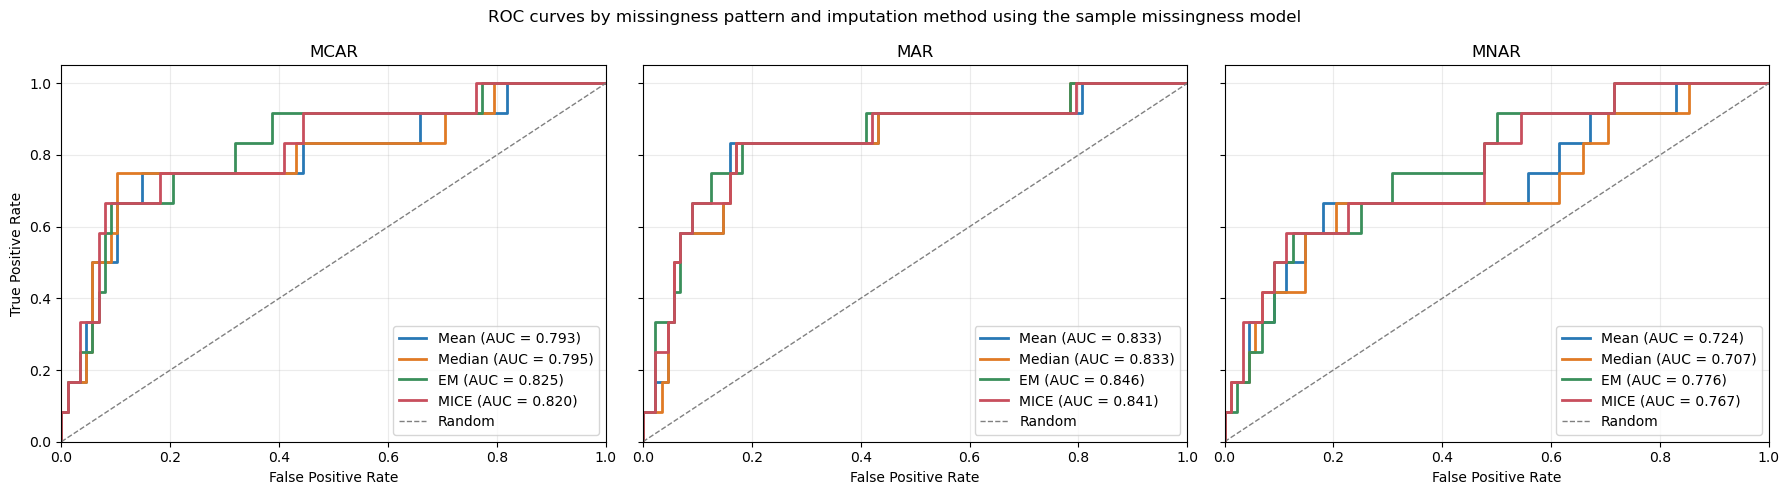

AUC by missingness pattern and imputation method:
Imputation      EM   MICE   Mean  Median
Missingness                             
MAR          0.846  0.841  0.833   0.833
MCAR         0.825  0.820  0.793   0.795
MNAR         0.776  0.767  0.724   0.707


In [6]:

# Existing notebook imputers / imputation patterns

def mean_impute(train_df, test_df):
    sat_col = train_df.columns[train_df.isna().any()][0]
    fill_value = train_df[sat_col].mean()
    return train_df.fillna({sat_col: fill_value}), test_df.fillna({sat_col: fill_value})


def median_impute(train_df, test_df):
    sat_col = train_df.columns[train_df.isna().any()][0]
    fill_value = train_df[sat_col].median()
    return train_df.fillna({sat_col: fill_value}), test_df.fillna({sat_col: fill_value})


def em_impute(train_df, test_df):
    train_arr = train_df.to_numpy(dtype=float).copy()
    test_arr = test_df.to_numpy(dtype=float).copy()
    train_imputed = pd.DataFrame(em_impute_mvn(train_arr), columns=train_df.columns)
    test_imputed = pd.DataFrame(em_impute_mvn(test_arr), columns=test_df.columns)
    return train_imputed, test_imputed


# TODO: update to fi
def mice_impute(train_df, test_df):
    imputer = IterativeImputer(
        estimator=BayesianRidge(),
        max_iter=20,
        random_state=42,
    )
    train_imp = pd.DataFrame(imputer.fit_transform(train_df), columns=train_df.columns)
    test_imp = pd.DataFrame(imputer.transform(test_df), columns=test_df.columns)
    return train_imp, test_imp


imputation_methods = {
    'Mean': mean_impute,
    'Median': median_impute,
    'EM': em_impute,
    'MICE': mice_impute,
}


def fit_sample_missingness_model(train_df, test_df, target_col='mortality_30_days'):
    """Fit the notebook's Bayesian missingness model to the train set and score the test set."""
    sat_col = [c for c in train_df.columns if 'saturation' in c][0]
    complaint_cols = [c for c in train_df.columns if c.startswith('chief_complaint')]

    # Scale continuous predictors using the training distribution only.
    age_mean = train_df['age'].mean()
    age_std = train_df['age'].std(ddof=0)
    if age_std == 0:
        age_std = 1.0

    sat_mean = train_df[sat_col].mean()
    sat_std = train_df[sat_col].std(ddof=0)
    if sat_std == 0:
        sat_std = 1.0

    X_train = train_df.copy()
    X_test = test_df.copy()
    y_train = X_train.pop(target_col).to_numpy()
    y_test = X_test.pop(target_col).to_numpy()

    X_train['age'] = (X_train['age'] - age_mean) / age_std
    X_test['age'] = (X_test['age'] - age_mean) / age_std
    X_train[sat_col] = (X_train[sat_col] - sat_mean) / sat_std
    X_test[sat_col] = (X_test[sat_col] - sat_mean) / sat_std

    age_train = X_train['age'].to_numpy()
    age_test = X_test['age'].to_numpy()
    female_train = X_train['gender'].to_numpy()
    female_test = X_test['gender'].to_numpy()
    sat_train = X_train[sat_col].to_numpy()
    sat_test = X_test[sat_col].to_numpy()
    complaint_train = X_train[complaint_cols].to_numpy()
    complaint_test = X_test[complaint_cols].to_numpy()

    with pm.Model() as model:
        intercept = pm.Normal('intercept', mu=0, sigma=1.5)
        w_age = pm.Normal('w_age', mu=0, sigma=1)
        w_female = pm.Normal('w_female', mu=0, sigma=1)
        w_sat = pm.Normal('w_sat', mu=0, sigma=1)
        w_complaints = pm.Normal('w_complaints', mu=0, sigma=1, shape=complaint_train.shape[1])

        log_odds = (
            intercept
            + w_age * age_train
            + w_female * female_train
            + w_sat * sat_train
            + pm.math.dot(complaint_train, w_complaints)
        )

        pm.Bernoulli('likelihood', logit_p=log_odds, observed=y_train)

        trace = pm.sample(
            draws=800,
            tune=400,
            chains=2,
            cores=1,
            target_accept=0.9,
            progressbar=False,
        )

    alpha = trace.posterior['intercept'].values.reshape(-1)
    beta_age = trace.posterior['w_age'].values.reshape(-1)
    beta_female = trace.posterior['w_female'].values.reshape(-1)
    beta_sat = trace.posterior['w_sat'].values.reshape(-1)
    beta_complaints = trace.posterior['w_complaints'].values.reshape(-1, complaint_train.shape[1])

    lin_test = (
        alpha[:, None]
        + beta_age[:, None] * age_test[None, :]
        + beta_female[:, None] * female_test[None, :]
        + beta_sat[:, None] * sat_test[None, :]
        + beta_complaints @ complaint_test.T
    )
    test_probs = 1 / (1 + np.exp(-lin_test)).mean(axis=0)
    return test_probs, y_test


results = []
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
colors = ['#2878B5', '#E07A25', '#3A8F5B', '#C84E5D']

# Benchmark loop across the three missingness patterns.
# For each pattern we keep the same train/test split, apply each imputation strategy,
# fit the sample missingness model and then compare AUC values across methods.
for ax, (pattern_name, sat_column) in zip(axes, missingness_patterns.items()):
    # Select the relevant saturation column for this mechanism and one-hot encode the complaint variable.
    pattern_df = df[['age', 'gender', 'chief_complaint', sat_column, 'mortality_30_days']].copy()
    pattern_df = pd.get_dummies(pattern_df, columns=['chief_complaint'], drop_first=True, dtype=float)

    # Separate features (X) from the binary target (y).
    X = pattern_df.drop(columns='mortality_30_days')
    y = pattern_df['mortality_30_days']

    # Split once per pattern for a fair comparison. We stratify on the outcome so the train
    # and test sets preserve the original mortality rate.
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.25,
        random_state=42,
        stratify=y,
    )

    # Reattach the target to the train/test frames so the imputer and model both see the target
    # in the same structure when they fit the sample missingness model.
    X_train = pd.concat([X_train, y_train], axis=1)
    X_test = pd.concat([X_test, y_test], axis=1)

    # Try each imputation method and score the same model on the resulting completed data.
    for method_name, method in imputation_methods.items():
        X_train_imp, X_test_imp = method(X_train.copy(), X_test.copy())
        test_probs, test_y = fit_sample_missingness_model(X_train_imp, X_test_imp)
        auc = roc_auc_score(test_y, test_probs)
        fpr, tpr, _ = roc_curve(test_y, test_probs)

        # Store one row per missingness pattern + imputation method so we can compare AUCs cleanly.
        results.append({
            'Missingness': pattern_name,
            'Imputation': method_name,
            'AUC': auc,
        })

        # Use a fixed color for each method so the ROC lines are readable across the three panels.
        color = colors[list(imputation_methods).index(method_name)]
        ax.plot(fpr, tpr, lw=2, color=color, label=f'{method_name} (AUC = {auc:.3f})')

    # Add the random classifier baseline as a reference line.
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1, label='Random')
    ax.set_title(pattern_name)
    ax.set_xlabel('False Positive Rate')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.25)
    ax.legend(loc='lower right')

axes[0].set_ylabel('True Positive Rate')
fig.suptitle('ROC curves by missingness pattern and imputation method using the sample missingness model')
fig.tight_layout()
plt.show()

# Pivot the results to a table with missingness patterns as rows and imputation method as columns.
summary_df = pd.DataFrame(results).pivot_table(index='Missingness', columns='Imputation', values='AUC')
print('AUC by missingness pattern and imputation method:')
print(summary_df.round(3).to_string())